In [ ]:
import asyncio
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import time
import copy
import glob
import os
import warnings
warnings.simplefilter("ignore")
import matplotlib.pyplot as plt

import torch
import signatory
from scipy.linalg import pinv
from collections import deque
import time
from hmmlearn.hmm import GaussianHMM


In [3]:
# root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-02-{27}"
# df = pd.read_parquet(os.path.join(root, '09_35.parquet'))

In [11]:
def read_pq(date: str, instrument: str | None = None,  exc: str | None = None):
    # read all the parquet file downloaded
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-{date}"

    all_files = glob.glob(
        "**/*.parquet",
        root_dir=root,
        recursive=True
    )

    df = pd.DataFrame()
    
    i = 1
    
    #club all the files into a single one
    for file_name in all_files:
        try:
            if instrument is None:
                _df = pd.read_parquet(os.path.join(root, file_name))
            else:
                _df = pd.read_parquet(os.path.join(root, file_name))
                _df = _df[_df['security_id'] == instrument]
        except:
            continue
        
        df = pd.concat([df, _df], axis= 0)
    
    '''
    compute the mid price and 
    normalize the price so that we are concerned of only the distance from centre
    '''
    __ask = df[df["side"] == "Ask"].groupby("snap_idx")["price"].min()
    __bid = df[df["side"] == "Bid"].groupby("snap_idx")["price"].max()
    __mid = 0.5*(__ask + __bid)

    df = df.reset_index(drop = True)
    df["price_norm"] = df["price"] - df["snap_idx"].map(__mid)
    
    # considering only NIFTY future with lot = 65
    if exc == 'fno':
        df["qty_norm"] = df["qty"] / 65 
    else:
        df["qty_norm"] = df["qty"]  
    
    return df, __mid
        
        

In [12]:
df_market, mid_price = read_pq('03-05', '2885')
# df_market, mid_price = read_pq('02-27', '51714', 'fno')


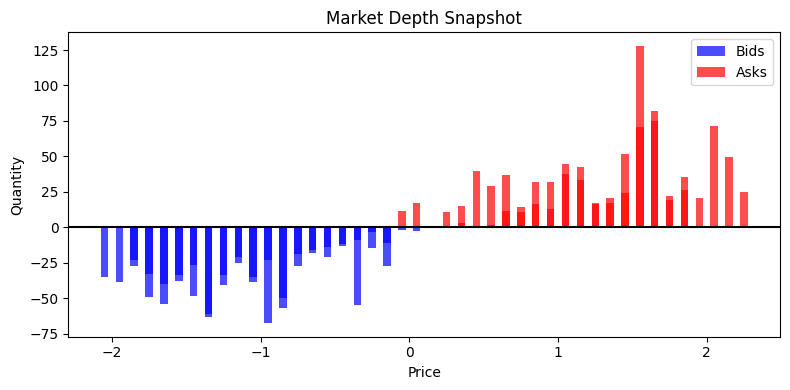

In [ ]:
# df_market = df_market.reset_index(drop= True)
#Define a snap view and plot it
snap = df_market[df_market["snap_idx"] == df_market["snap_idx"][0]]
# Bids and Asks
bids = snap[snap["side"] == "Bid"].sort_values("price_norm", ascending=False)
asks = snap[snap["side"] == "Ask"].sort_values("price_norm")
#set up the plt()
plt.figure(figsize=(8, 4))
# Bars
plt.bar(bids["price_norm"],-bids["qty_norm"],width=0.05,color="blue",alpha=0.7,label="Bids")
plt.bar(asks["price_norm"],asks["qty_norm"],width=0.05,color="red",alpha=0.7,label="Asks")

plt.axhline(0, color="black")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.title(f"Market Depth Snapshot")
plt.legend()

plt.tight_layout()
plt.show()

In [105]:
df_bid = (
    df_market[df_market["side"] == "Bid"]
    .sort_values(["snap_idx", "price"], ascending=[True, False])
    .groupby("snap_idx")
    .first()[["price", "qty"]]
    .rename(columns={"price": "price_bid", "qty": "qty_bid"})
)

df_ask = (
    df_market[df_market["side"] == "Ask"]
    .sort_values(["snap_idx", "price"], ascending=[True, True])
    .groupby("snap_idx")
    .first()[["price", "qty"]]
    .rename(columns={"price": "price_ask", "qty": "qty_ask"})
)

df_l1 = df_bid.join(df_ask).reset_index()

In [ ]:
class OrderBookHMM:

    def __init__(self, n_states=3):

        self.model = GaussianHMM(
            n_components=n_states,
            covariance_type="full",
            n_iter=200
        )

        self.fitted = False

        self.prev_micro_price = None
        self.prev_mid = None

        # state labels (can be changed after training)
        self.state_labels = {
            0: "MM",
            1: "UPWARD",
            2: "DOWNWARD"
        }

    # --------------------------------
    # feature extraction
    # --------------------------------

    def compute_features(self, bid, ask, bid_qty, ask_qty):

        denom = bid_qty + ask_qty
        if denom == 0:
            return None

        mid = (bid + ask) / 2

        micro_price = (ask * bid_qty + bid * ask_qty) / denom

        if self.prev_mid is None:
            self.prev_mid = mid
            return None

        if self.prev_micro_price is None:
            self.prev_micro_price = micro_price
            return None

        # microprice return
        ret = np.log(micro_price / self.prev_micro_price)

        spread = ask - bid

        imbalance = (bid_qty - ask_qty) / denom

        # NEW FEATURE
        volume_pressure = np.log((bid_qty + 1) / (ask_qty + 1))

        self.prev_mid = mid
        self.prev_micro_price = micro_price

        return np.array([ret, spread, imbalance, volume_pressure])

    # --------------------------------
    # train model
    # --------------------------------

    def fit(self, data):

        self.model.fit(data)

        self.fitted = True

    # --------------------------------
    # infer regime
    # --------------------------------

    def predict_state(self, feature):

        if feature is None or not self.fitted:
            return None

        state = int(self.model.predict(feature.reshape(1, -1))[0])

        return {
            "state_id": state,
            "state": self.state_labels.get(state, "UNKNOWN")
        }

In [138]:
def compute_hmm_states(df, n_states=3):

    df = df.copy()

    hmm_detector = OrderBookHMM(n_states=n_states)

    # ----------------------------
    # Build feature matrix
    # ----------------------------

    features = []

    for row in df.itertuples():

        f = hmm_detector.compute_features(
            row.price_bid,
            row.price_ask,
            row.qty_bid,
            row.qty_ask
        )

        if f is not None:
            features.append(f)

    features = np.array(features)

    # ----------------------------
    # Train HMM
    # ----------------------------

    hmm_detector.fit(features)

    # ----------------------------
    # Reset state
    # ----------------------------

    hmm_detector.prev_mid = None
    hmm_detector.prev_micro_price = None

    # ----------------------------
    # Predict regimes
    # ----------------------------

    states = []

    for row in df.itertuples():

        f = hmm_detector.compute_features(
            row.price_bid,
            row.price_ask,
            row.qty_bid,
            row.qty_ask
        )

        states.append(hmm_detector.predict_state(f))

    df["state_info"] = states

    df["state_id"] = df["state_info"].apply(
        lambda x: x["state_id"] if x else None
    )

    df["state"] = df["state_info"].apply(
        lambda x: x["state"] if x else None
    )

    return df, hmm_detector

In [145]:
df_bid_ask_subset = df_l1.iloc[:2000].copy()
df_result, hmm_model = compute_hmm_states(df_bid_ask_subset)
df_result['state'].value_counts()


state
DOWNWARD    1253
MM           630
UPWARD       115
Name: count, dtype: int64

### Markov LOB

In [ ]:
class MarkovLOB:

    def __init__(self,
                 window=200,
                 mm_threshold=0.01,
                 band_k=2):

        self.window = window
        self.mm_threshold = mm_threshold
        self.band_k = band_k

        self.prev_microprice = None

        self.microprice_window = deque(maxlen=window)

        self.mu = None
        self.var_stationary = None

        self.lower_bound = None
        self.upper_bound = None

    # ---------------------------------
    # microprice
    # ---------------------------------

    def microprice(self, bid, ask, bid_qty, ask_qty):

        denom = bid_qty + ask_qty
        if denom == 0:
            return None

        return (ask * bid_qty + bid * ask_qty) / denom

    # ---------------------------------
    # estimate OU parameters
    # ---------------------------------

    def estimate_ou(self, data):

        x = np.array(data)

        x_t = x[:-1]
        x_next = x[1:]

        A = np.vstack([x_t, np.ones(len(x_t))]).T
        a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]

        residuals = x_next - (a * x_t + b)
        sigma2 = np.var(residuals)

        # mean of stationary distribution
        mu = b / (1 - a)

        # stationary variance
        var_stat = sigma2 / (1 - a**2)

        return mu, var_stat

    # ---------------------------------
    # update
    # ---------------------------------

    def update(self, bid, ask, bid_qty, ask_qty):

        mp = self.microprice(bid, ask, bid_qty, ask_qty)

        if mp is None:
            return None

        if self.prev_microprice is None:
            self.prev_microprice = mp
            return None

        dmp = mp - self.prev_microprice

        is_mm = abs(dmp) < self.mm_threshold

        if is_mm:
            self.microprice_window.append(mp)

        if len(self.microprice_window) > 30:

            mu, var_stat = self.estimate_ou(self.microprice_window)

            std = np.sqrt(var_stat)

            self.mu = mu
            self.lower_bound = mu - self.band_k * std
            self.upper_bound = mu + self.band_k * std

        self.prev_microprice = mp

        return {
            "microprice": mp,
            "mu": self.mu,
            "lower_bound": self.lower_bound,
            "upper_bound": self.upper_bound,
            "is_mm": is_mm
        }

In [136]:
def compute_mm_bounds(df, window=200, band_k=2, plot=True):

    df = df.copy()

    # ----------------------------
    # Run MarkovLOB estimator
    # ----------------------------

    markov_lob = MarkovLOB(window=window, band_k=band_k)

    results = []

    for row in df.itertuples():

        res = markov_lob.update(
            row.price_bid,
            row.price_ask,
            row.qty_bid,
            row.qty_ask
        )

        results.append(res)

    df["lob_info"] = results

    # ----------------------------
    # Extract microprice + OU bounds
    # ----------------------------

    df["microprice"] = df["lob_info"].apply(
        lambda x: x["microprice"] if x else None
    )

    df["lower_bound"] = df["lob_info"].apply(
        lambda x: x["lower_bound"] if x else None
    )

    df["upper_bound"] = df["lob_info"].apply(
        lambda x: x["upper_bound"] if x else None
    )

    # ----------------------------
    # Convert to bid/ask bounds
    # ----------------------------

    spread = df["price_ask"] - df["price_bid"]

    df["bid_bound"] = df["lower_bound"] - spread / 2
    df["ask_bound"] = df["upper_bound"] + spread / 2

    # ----------------------------
    # Enforce microstructure constraints
    # ----------------------------

    df["bid_bound"] = np.minimum(df["bid_bound"], df["price_bid"])

    df["ask_bound"] = np.maximum(df["ask_bound"], df["price_ask"])

    mask = df["bid_bound"] > df["ask_bound"]

    df.loc[mask, "bid_bound"] = df.loc[mask, "price_bid"]
    df.loc[mask, "ask_bound"] = df.loc[mask, "price_ask"]

    # ----------------------------
    # Plot (optional)
    # ----------------------------

    if plot:

        plt.figure(figsize=(14,6))

        plt.plot(df["price_bid"], label="Bid", alpha=0.7)
        plt.plot(df["price_ask"], label="Ask", alpha=0.7)

        plt.plot(df["bid_bound"], label="Bid Bound", linestyle="--")
        plt.plot(df["ask_bound"], label="Ask Bound", linestyle="--")

        plt.legend()
        plt.title("Bid / Ask with Market-Making Bounds")
        plt.xlabel("Time")
        plt.ylabel("Price")

        plt.show()

    return df

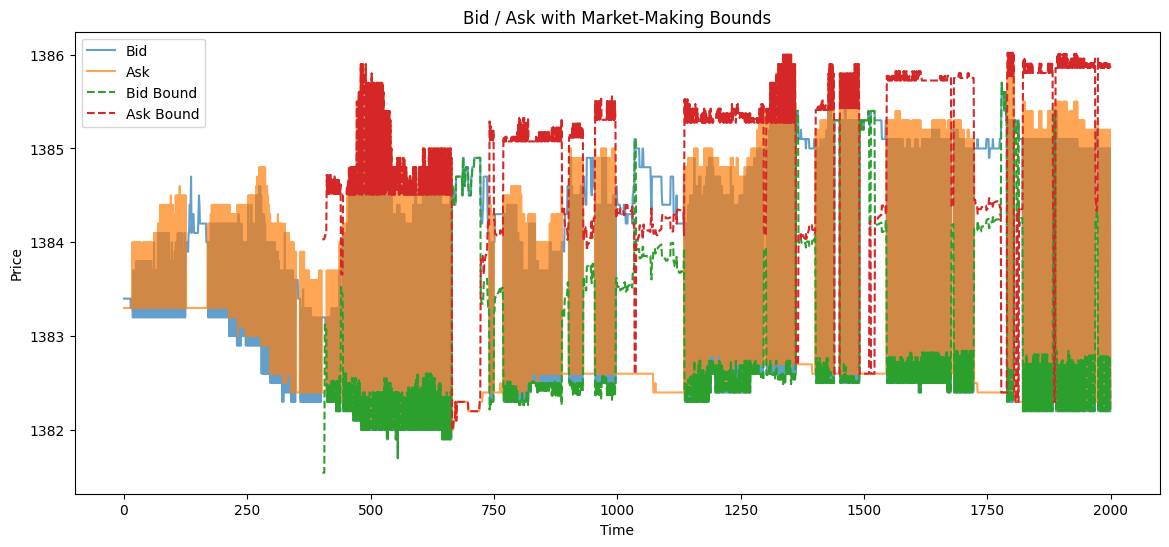

In [137]:
df_result = compute_mm_bounds(df_bid_ask_subset)